# 3 · The finite element solver

Bars and Euler–Bernoulli frames, sparse assembly, and a convergence study. Theory:
[docs/fea_solver.md](../docs/fea_solver.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from structures import plotting as P

P.use_style()
DEG = np.pi / 180
MPA = 1e6
from structures.fea_solver import Model, beam_model
from structures.beam_theory import closed_form

In [2]:
# Two-panel truss: A(0,0) B(2,0) C(4,0) D(2,1.5), 10 kN down at B
m = Model()
A, B, C, D = (m.add_node(*p) for p in [(0, 0), (2, 0), (4, 0), (2, 1.5)])
names = {}
for k, (i, j) in {"AB": (A, B), "BC": (B, C), "AD": (A, D), "DC": (D, C), "BD": (B, D)}.items():
    names[k] = m.add_bar(i, j, 200e9, 1e-3)
m.fix(A, "xy").fix(C, "y").load(B, fy=-10e3)
s = m.solve()
for k, e in names.items():
    print(f"{k}: {s.axial_force(e)/1e3:+8.3f} kN")
print("reactions (kN):", (s.reaction(A)[:2] / 1e3).round(3) + 0, (s.reaction(C)[:2] / 1e3).round(3) + 0)

AB:   +6.667 kN
BC:   +6.667 kN
AD:   -8.333 kN
DC:   -8.333 kN
BD:  +10.000 kN
reactions (kN): [0. 5.] [0. 5.]


In [3]:
L, E, A_, I = 3.0, 70e9, 4e-4, 2e-6
ref = closed_form.simply_supported_udl(2e3, L, E * I)["deflection"]
for n in (2, 4, 8):
    for lumped in (False, True):
        mdl = beam_model(L, n, E, A_, I)
        mdl.fix(0, "xy").fix(n, "y")
        for e in range(n):
            mdl.distributed(e, -2e3, lumped=lumped)
        v = -mdl.solve().displacement(n // 2)[1]
        print(f"n = {n}, {'lumped    ' if lumped else 'consistent'}: error {abs(v - ref)/ref:.2e}")

n = 2, consistent: error 0.00e+00
n = 2, lumped    : error 2.00e-01
n = 4, consistent: error 3.45e-16
n = 4, lumped    : error 5.00e-02
n = 8, consistent: error 3.57e-14
n = 8, lumped    : error 1.25e-02


Consistent loads give exact nodal deflections on every mesh (Tong's theorem); lumped loads converge as h².

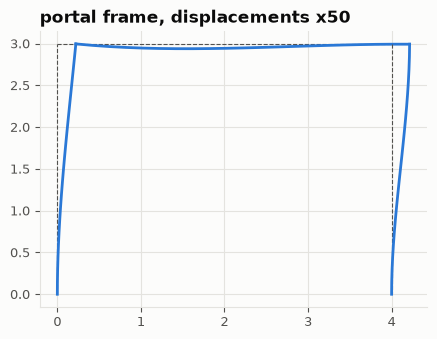

In [4]:
# Portal frame: deflected shape
m = Model()
n = [m.add_node(0, 0), m.add_node(0, 3), m.add_node(4, 3), m.add_node(4, 0)]
for i in range(3):
    m.add_frame(n[i], n[i + 1], 200e9, 5e-3, 8e-5)
m.fix(n[0]).fix(n[3]).distributed(1, -20e3).load(n[1], fx=40e3)
s = m.solve()
fig, ax = plt.subplots(figsize=(5, 4))
for e in range(3):
    d0 = s.deflected_shape(e, scale=0); d = s.deflected_shape(e, scale=50)
    ax.plot(*d0.T, color=P.TEXT_MUTED, ls="--", lw=0.8); ax.plot(*d.T, color=P.SERIES[0])
ax.set_aspect("equal"); ax.set_title("portal frame, displacements x50");